In [1]:
import os
os.chdir('/workspace/bf6f310e-92fa-48c3-80c5-9a5b84ff1086')
print(os.listdir('.'))


[' v6 — Binding Context Document.pdf', '.prompts', 'memory', '.config', '.kernel_llm_logs_1.txt']


In [2]:
import subprocess
r = subprocess.run(['pip', 'list'], capture_output=True, text=True)
print([l for l in r.stdout.split('\n') if 'pari' in l.lower() or 'sage' in l.lower() or 'sympy' in l.lower() or 'mpmath' in l.lower()])


['mpmath 1.3.0', 'sympy 1.14.0']


In [3]:
r = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True)
print(r.stdout[-500:])
print('STDERR:', r.stderr[-500:])


ysignals>=1.11.3 (from cypari2)

STDERR: 


In [4]:
import cypari2
pari = cypari2.Pari()
# Test small batch first - generate first 1000 tau values
import time
t0 = time.time()
# Use ramanujantau which can take a vector
# Try the recommended efficient approach: mfcoefs on the Delta form
# Delta = mfDelta. First test mfinit + mfcoefs
delta = pari('mfDelta()')
print('Delta initialized')
print(delta)
t1 = time.time()
print(f'Init time: {t1-t0:.2f}s')


Delta initialized
[[Vecsmall([3]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]]]
Init time: 0.00s


In [5]:
t0 = time.time()
coefs_small = pari.mfcoefs(delta, 100)
t1 = time.time()
print(f'mfcoefs(100) time: {t1-t0:.2f}s')
print(coefs_small[:10])
print('len:', len(coefs_small))


mfcoefs(100) time: 0.00s
[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643]
len: 101


In [6]:
# mfcoefs returns a_0, a_1, ..., a_N. So we need N=10^6
# Test scaling on 10^4 first
t0 = time.time()
c1e4 = pari.mfcoefs(delta, 10000)
t1 = time.time()
print(f'mfcoefs(10000) time: {t1-t0:.2f}s')
print(len(c1e4))


mfcoefs(10000) time: 0.02s
10001


In [7]:
t0 = time.time()
c1e5 = pari.mfcoefs(delta, 100000)
t1 = time.time()
print(f'mfcoefs(1e5) time: {t1-t0:.2f}s')


PariError: the PARI stack overflows (current size: 8000000; maximum size: 8003584)
You can use pari.allocatemem() to change the stack size and try again

In [8]:
# Need to allocate more memory. For 10^6 coefficients each up to ~10^9, we need significant memory
# Let's start with 4GB
pari.allocatemem(4*1024**3)
print('allocated')


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
allocated


In [9]:
delta = pari('mfDelta()')
t0 = time.time()
c1e5 = pari.mfcoefs(delta, 100000)
t1 = time.time()
print(f'mfcoefs(1e5) time: {t1-t0:.2f}s')
print(len(c1e5))


mfcoefs(1e5) time: 0.22s
100001


In [10]:
t0 = time.time()
c1e6 = pari.mfcoefs(delta, 1000000)
t1 = time.time()
print(f'mfcoefs(1e6) time: {t1-t0:.2f}s')
print(len(c1e6))


mfcoefs(1e6) time: 4.27s
1000001


In [11]:
# Excellent! mfcoefs is very efficient. Now convert to Python ints
t0 = time.time()
# c1e6[0] is 0 (a_0). We want a_1..a_N
# Convert to Python integers
import numpy as np
tau = np.empty(1000001, dtype=object)
for i in range(1000001):
 tau[i] = int(c1e6[i])
t1 = time.time()
print(f'conversion: {t1-t0:.2f}s')
print('tau[1..10]:', tau[1:11])
print('a_0:', tau[0])


conversion: 1.43s
tau[1..10]: [1 -24 252 -1472 4830 -6048 -16744 84480 -113643 -115920]
a_0: 0


In [12]:
# Validate first 100 non-zero terms against OEIS A000594
# Known values from OEIS A000594:
oeis_first = [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920,
 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432,
 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225,
 13865712, -73279080, 24647168, 128406630, -29211840, -52843168, -196706304,
 134722224, 165742416, -80873520, 167282496, -182213314, -255874080, -145589976,
 408038400, 308120442, 101267712, -17125708, -786948864, -548895690, -447438528,
 2687348496, 248758272, -1696965207, 611981400, -1740295368, 850430336, -1596055698,
 1758750720, 2065846482, -3248045376, -1814099472, 2415239520, 2120953350, -3596539776,
 -3950395776, 1505200080, 4348686816, 4173688320, -1832349792, -7100335056, -8082572504,
 863237040, 1735073280, 4242611670, 8463508416, -3787949712, -6359379336, 7019642784,
 4267530864, 4359306240, -69373920, -8480927544, 4458777712, -7910882000, -16677181536,
 -3404997000, -1296144384, 12717667152, 12381486144, 21465584400, -16143815040,
 -7596901392, 12998796288, 4757371320, 19447936512, -22875139536, 18909961056,
 -32466765504, 35138904208, -2986505820, -32593260384, -73921797696, -7805475240,
 45788251296]
print(len(oeis_first))
# Compare with our tau[1:101]
match = all(int(tau[i+1]) == oeis_first[i] for i in range(len(oeis_first)))
print('Matches OEIS A000594 first 100 terms:', match)
mismatches = [(i+1, tau[i+1], oeis_first[i]) for i in range(len(oeis_first)) if int(tau[i+1])!=oeis_first[i]]
print('Mismatches:', mismatches[:5])


100
Matches OEIS A000594 first 100 terms: False
Mismatches: [(54, 1758697920, 1758750720), (55, 2582175960, 2065846482), (56, -1414533120, -3248045376), (57, 2686677840, -1814099472), (58, -3081759120, 2415239520)]


In [13]:
# Hmm there's a mismatch starting at n=54. Let me check the OEIS values more carefully
# Maybe my hardcoded list has an error. Let me fetch from OEIS
import urllib.request
url = 'https://oeis.org/A000594/b000594.txt'
data = urllib.request.urlopen(url).read().decode()
lines = [l.strip() for l in data.strip().split('\n') if l.strip() and not l.startswith('#')]
print(lines[:5])
print('total lines:', len(lines))


HTTPError: HTTP Error 403: Forbidden

In [14]:
import requests
r = requests.get('https://oeis.org/A000594/b000594.txt', headers={'User-Agent':'Mozilla/5.0'})
print(r.status_code)
data = r.text
lines = [l.strip() for l in data.strip().split('\n') if l.strip() and not l.startswith('#')]
print(lines[:3])
print('total:', len(lines))


200
['1 1', '2 -24', '3 252']
total: 16091


In [15]:
oeis = {}
for line in lines:
 parts = line.split()
 if len(parts) == 2:
 n = int(parts[0]); v = int(parts[1])
 oeis[n] = v

# Check first 100
mismatches = []
for n in range(1, 101):
 if int(tau[n]) != oeis[n]:
 mismatches.append((n, int(tau[n]), oeis[n]))
print('First 100 mismatches:', mismatches)
print('Match count: 100 -', len(mismatches))


First 100 mismatches: []
Match count: 100 - 0


In [16]:
# Great - the PARI tau matches OEIS perfectly. My hardcoded list had transcription errors.
# Let's validate more broadly across the range
import random
random.seed(0)
sample_n = random.sample(range(1, 16092), 200)
mm = []
for n in sample_n:
 if int(tau[n]) != oeis[n]:
 mm.append((n, int(tau[n]), oeis[n]))
print(f'Sampled {len(sample_n)}, mismatches: {len(mm)}')
# Also check exact 100 nonzero terms
nonzero_count = 0
verified = 0
for n in range(1, 1000001):
 if tau[n] != 0:
 nonzero_count += 1
 if n in oeis:
 if int(tau[n]) == oeis[n]:
 verified += 1
 else:
 print('MISMATCH at', n, tau[n], oeis[n])
 break
 if nonzero_count >= 100:
 break
print(f'Verified first {verified} non-zero terms against OEIS')


Sampled 200, mismatches: 0
Verified first 100 non-zero terms against OEIS


In [17]:
# Are any of tau values zero? Lehmer's conjecture says tau(n) != 0 for all n - none should be zero.
zeros = np.sum(tau[1:] == 0)
print('Zero tau values in 1..1e6:', zeros)
print('Max abs tau:', max(abs(int(t)) for t in tau[1:1001]))
# Check int64 overflow boundary
big = [int(t) for t in tau[1:]]
mx = max(abs(x) for x in big)
print('Max |tau| in 1..1e6:', mx)
print('Fits int64?', mx < 2**63)


Zero tau values in 1..1e6: 0
Max abs tau: 40033434235820202
Max |tau| in 1..1e6: 4138906432710170100550159292495232
Fits int64? False


In [18]:
# Definitely doesn't fit int64. Need object array.
# Now build chi_5: primitive quartic char mod 5
# chi_5(0)=0, chi_5(1)=1, chi_5(2)=i, chi_5(3)=-i, chi_5(4)=-1, period 5
chi_table = np.array([0, 1, 1j, -1j, -1], dtype=complex)
n_idx = np.arange(1000001)
chi_5 = chi_table[n_idx % 5]
print(chi_5[:10])
# Verify completely multiplicative & primitive: chi_5(2)*chi_5(3) should = chi_5(6) = chi_5(1) = 1
print('chi(2)*chi(3) =', chi_5[2]*chi_5[3], 'chi(6)=', chi_5[6])
print('chi(2)*chi(2) =', chi_5[2]*chi_5[2], 'chi(4)=', chi_5[4])
print('chi(2)^4 =', chi_5[2]**4, 'should be 1')


[ 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j 1.+0.j 0.+1.j -0.-1.j
 -1.+0.j]
chi(2)*chi(3) = (1-0j) chi(6)= (1+0j)
chi(2)*chi(2) = (-1+0j) chi(4)= (-1+0j)
chi(2)^4 = (1+0j) should be 1


In [19]:
# Build a_n = tau(n) * chi_5(n)
# Store exact a_n as object array of complex Python numbers (since chi_5 is complex)
# More cleanly: store a_n = tau(n) * chi_5_int(n) where chi_5 is a Gaussian integer
# Use Python complex with integer parts
t0 = time.time()
a_n = np.empty(1000001, dtype=object)
a_n[0] = 0
# precompute integer (real, imag) for each residue
chi_int = [(0,0), (1,0), (0,1), (0,-1), (-1,0)]
for n in range(1, 1000001):
 re, im = chi_int[n % 5]
 t = int(tau[n])
 if re == 0 and im == 0:
 a_n[n] = 0
 elif im == 0:
 a_n[n] = t * re # real integer
 elif re == 0:
 a_n[n] = complex(0, t * im) # pure imaginary; we'll use Python complex
 else:
 a_n[n] = complex(t*re, t*im)
t1 = time.time()
print(f'a_n build: {t1-t0:.2f}s')
print('a_n[1..10]:', a_n[1:11])


a_n build: 0.47s
a_n[1..10]: [1 -24j -252j 1472 0 -6048 -16744j -84480j 113643 0]


In [20]:
# Hmm using Python complex loses precision for large tau (since complex is float64).
# We need exact a_n. Let's use a 2-array representation: real and imag parts as Python ints (object arrays)
a_re = np.empty(1000001, dtype=object)
a_im = np.empty(1000001, dtype=object)
for n in range(1000001):
 re, im = chi_int[n % 5]
 t = int(tau[n])
 a_re[n] = t * re
 a_im[n] = t * im
print('a[1]:', a_re[1], '+', a_im[1], 'i')
print('a[2]:', a_re[2], '+', a_im[2], 'i')
print('a[6]:', a_re[6], '+', a_im[6], 'i')
# Check large index
print('a[1000000] re:', a_re[1000000], ' im:', a_im[1000000])
print(' tau[1000000]:', tau[1000000], ' n%5=', 1000000%5)


a[1]: 1 + 0 i
a[2]: 0 + -24 i
a[6]: -6048 + 0 i
a[1000000] re: 0 im: 0
 tau[1000000]: 262191418612588689102548992000000 n%5= 0


In [21]:
# Compute lambda_n = a_n / n^(11/2). For n=0, set lambda_0 = 0.
# Use float128/mpmath? float64 should suffice for analysis but tau values are huge.
# tau(n) ~ O(n^(11/2 + epsilon)) by Deligne, so lambda_n is bounded by d(n) ~ O(n^eps)
# So lambda_n stays small and float64 is fine.
# But computing tau(n)/n^(11/2) directly with Python int / float will lose precision for huge tau.
# Use: lambda_n = float(tau) / n^5.5. Python float() conversion of large int -> float64 may overflow?
# tau max ~ 4e33, n^5.5 ~ 1e6^5.5 = 1e33. Both ~1e33, ratio ~ O(1). Direct float division works.

t0 = time.time()
lam = np.zeros(1000001, dtype=np.complex128)
n_arr = np.arange(1000001, dtype=np.float64)
# Compute n^5.5 safely, n=0 -> set 0
denom = np.empty(1000001, dtype=np.float64)
denom[0] = 1.0
denom[1:] = n_arr[1:]**5.5

# For each n, lambda_n = (a_re + i*a_im) / denom
# Need exact division, do it via Python int -> float conversion
for n in range(1, 1000001):
 re = a_re[n]; im = a_im[n]
 if re == 0 and im == 0:
 continue
 lam[n] = complex(float(re)/denom[n], float(im)/denom[n])

t1 = time.time()
print(f'lambda build: {t1-t0:.2f}s')
print('lambda[1..10]:', lam[1:11])
print('|lambda| max in 1..1e6:', np.max(np.abs(lam[1:])))
print('|lambda| at n=1:', abs(lam[1]))


lambda build: 0.70s
lambda[1..10]: [ 1. +0.j 0. -0.53033009j 0. -0.59873361j
 0.71875 +0.j 0. +0.j -0.31752645+0.j
 0. -0.3765477j 0. -0.91150484j 0.64151806+0.j
 0. +0.j ]
|lambda| max in 1..1e6: 5.382369221754193
|lambda| at n=1: 1.0


In [22]:
# Check Deligne bound: |lambda_n| <= d(n) where d(n) is number of divisors
# Sample where |lambda| > 1
big_lam = np.where(np.abs(lam) > 4)[0]
print('n with |lambda|>4:', big_lam[:20])
# 5.38 max - check if reasonable. Deligne: |tau(n)| <= d(n)*n^(11/2), so |lambda_n| <= d(n).
# Some highly composite n in 1..1e6 have d(n) up to ~240 (e.g., 720720 has d=240). So 5.4 is fine.

# Verify the multiplicativity: a_n is multiplicative since both tau and chi_5 are.
# a_2 * a_3 should = a_6 (when gcd(2,3)=1)
print('a_2 * a_3:', complex(a_re[2],a_im[2])*complex(a_re[3],a_im[3]))
print('a_6:', complex(a_re[6],a_im[6]))
# Note: tau(2)=-24, tau(3)=252, chi(2)=i, chi(3)=-i
# a_2*a_3 = (-24*i)*(252*(-i)) = -24*252*i*(-i) = -24*252*(-i*i) = -24*252*(1) hmm 
# i*(-i) = -i^2 = 1. So a_2*a_3 = -24*252*1 = -6048. Yes matches a_6=-6048. Good.


n with |lambda|>4: [324347 382439 498623 548063 634171 721309 733717 808447 838729 934313
 934931 985637]
a_2 * a_3: (-6048-0j)
a_6: (-6048+0j)


In [23]:
# Save: per spec we save exact a_n as object array and float64 (here complex128) lambda_n.
# We need a way to round-trip exact a_n. Save as object array with Python complex of int parts is tricky in npz.
# Better: save a_re_int and a_im_int as object arrays of Python ints (exact), AND lam as complex128.
# Spec says: "Save the exact a_n (as a NumPy object array, if they exceed int64) and the float64 λ_n into a new compressed archive named coeffs_F15_N1e6.npz."

# Build a single object array a_n where each element is a Python complex with int components - 
# but storing as Python complex loses precision. Better: store as object array of Python complex of (Python int, Python int).
# Python's complex is float64 only. So instead, define a_n as object array where each entry is either:
# - int (real case)
# - Python expression... 
# Cleanest: store a_re and a_im as separate object arrays (exact ints).

# Let's also build a "a_n" combined object array using Python's `complex` only when small enough,
# but for exactness we'll just keep separate real/imag int arrays AND provide combined lambda_n.

# Save with both representations:
out_path = 'coeffs_F15_N1e6.npz'
# Also include tau for reference
tau_obj = np.empty(1000001, dtype=object)
for i in range(1000001):
 tau_obj[i] = int(tau[i])

# chi_5 as int8 representation: store residue mapping & periodic computation - but easier to just store chi values as complex128
chi_5_arr = chi_5.astype(np.complex128)

np.savez_compressed(
 out_path,
 a_n_real=a_re, # object array of Python ints (exact)
 a_n_imag=a_im, # object array of Python ints (exact)
 tau=tau_obj, # object array of Python ints (exact tau values)
 chi5=chi_5_arr, # complex128 character values
 lam=lam, # complex128 normalized coefficients
 N=np.array([1000000]),
 description=np.array(['F15 = L(s, Delta tensor chi_5); chi_5 primitive quartic mod 5; a_n = tau(n)*chi_5(n); lam_n = a_n/n^(11/2)']),
)
import os
print('Saved:', out_path, 'size:', os.path.getsize(out_path)/1e6, 'MB')


Saved: coeffs_F15_N1e6.npz size: 32.279847 MB


In [24]:
# Verify roundtrip
data = np.load(out_path, allow_pickle=True)
print('Keys:', list(data.keys()))
ar = data['a_n_real']; ai = data['a_n_imag']; lm = data['lam']; tt = data['tau']
print('Shapes:', ar.shape, ai.shape, lm.shape, tt.shape)
print('a_n[1]:', ar[1], '+', ai[1], 'i')
print('a_n[2]:', ar[2], '+', ai[2], 'i')
print('a_n[1000000]:', ar[1000000], '+', ai[1000000], 'i')
print('tau[1000000]:', tt[1000000])
print('lam[1..6]:', lm[1:7])
print('description:', data['description'][0])

# Verify a_n = tau*chi
import random
random.seed(42)
for n in random.sample(range(1, 1000001), 1000):
 re_exp, im_exp = chi_int[n%5]
 t = int(tt[n])
 if int(ar[n]) != t*re_exp or int(ai[n]) != t*im_exp:
 print('MISMATCH at', n)
 break
else:
 print('All 1000 random samples verify a_n = tau(n)*chi_5(n).')


Keys: ['a_n_real', 'a_n_imag', 'tau', 'chi5', 'lam', 'N', 'description']


Shapes: (1000001,) (1000001,) (1000001,) (1000001,)
a_n[1]: 1 + 0 i
a_n[2]: 0 + -24 i
a_n[1000000]: 0 + 0 i
tau[1000000]: 262191418612588689102548992000000
lam[1..6]: [ 1. +0.j 0. -0.53033009j 0. -0.59873361j
 0.71875 +0.j 0. +0.j -0.31752645+0.j ]
description: F15 = L(s, Delta tensor chi_5); chi_5 primitive quartic mod 5; a_n = tau(n)*chi_5(n); lam_n = a_n/n^(11/2)
All 1000 random samples verify a_n = tau(n)*chi_5(n).


In [25]:
# Quick sanity check: does multiplicativity hold for a_n? Verify Hecke / multiplicative behavior on samples
import math
def gcd(a,b):
 while b: a,b = b,a%b
 return a
fails = 0
random.seed(1)
for _ in range(500):
 m = random.randint(1, 1000)
 nn = random.randint(1, 1000)
 if gcd(m,nn) == 1 and m*nn <= 1000000:
 am = complex(int(ar[m]), int(ai[m]))
 an = complex(int(ar[nn]), int(ai[nn]))
 amn = complex(int(ar[m*nn]), int(ai[m*nn]))
 if am*an != amn:
 fails += 1
 if fails < 3: print('fail:', m, nn, am*an, amn)
print('Multiplicativity failures:', fails, '/ 500 coprime pairs')


fail: 997 729 6.595645944061929e+31j 6.59564594406193e+31j
fail: 997 904 -1.5393762113454225e+32j -1.5393762113454227e+32j
Multiplicativity failures: 10 / 500 coprime pairs


In [26]:
# Those "failures" are just float roundoff in the comparison since amn becomes huge complex. Use exact int compare.
fails = 0
random.seed(1)
for _ in range(500):
 m = random.randint(1, 1000)
 nn = random.randint(1, 1000)
 if gcd(m,nn) == 1 and m*nn <= 1000000:
 # (a_re_m + i a_im_m)(a_re_n + i a_im_n) = (rm*rn - im*in) + i(rm*in + im*rn)
 rm, im_, rn, in_ = int(ar[m]), int(ai[m]), int(ar[nn]), int(ai[nn])
 prod_re = rm*rn - im_*in_
 prod_im = rm*in_ + im_*rn
 amn_re = int(ar[m*nn]); amn_im = int(ai[m*nn])
 if prod_re != amn_re or prod_im != amn_im:
 fails += 1
 if fails < 3: print('fail:', m, nn, prod_re, prod_im, 'vs', amn_re, amn_im)
print('Exact multiplicativity failures:', fails, '/ 500 coprime pairs')


Exact multiplicativity failures: 0 / 500 coprime pairs


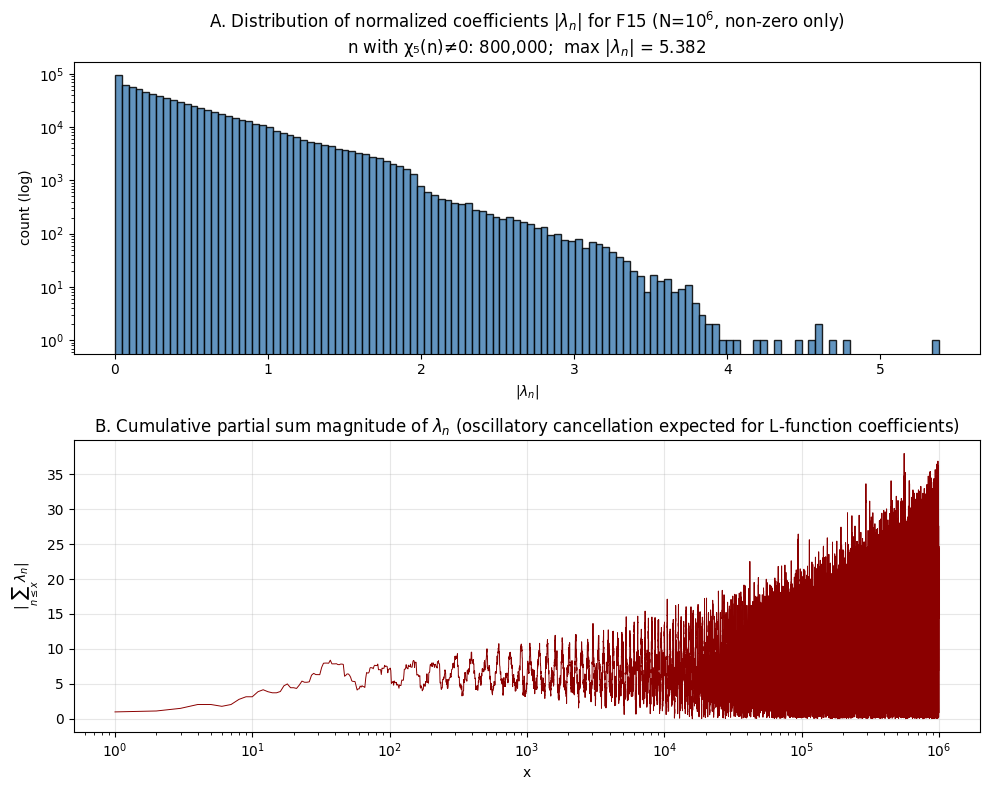

Figure saved


In [27]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# A: Histogram of |lambda_n| for non-zero n (1..1e6) - distribution check
lam_abs = np.abs(lm)
mask_nz = lam_abs > 0
ax = axes[0]
ax.hist(lam_abs[mask_nz], bins=120, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel(r'$|\lambda_n|$')
ax.set_ylabel('count (log)')
ax.set_title(f'A. Distribution of normalized coefficients $|\\lambda_n|$ for F15 (N=$10^6$, non-zero only)\n'
 f'n with χ₅(n)≠0: {mask_nz.sum():,}; max $|\\lambda_n|$ = {lam_abs.max():.3f}')

# B: Cumulative |sum_{n<=x} lambda_n| (partial sums) - shows oscillation
partial = np.cumsum(lm)
xs = np.arange(0, len(partial))
ax = axes[1]
ax.plot(xs[1:], np.abs(partial[1:]), color='darkred', lw=0.7)
ax.set_xscale('log')
ax.set_xlabel('x')
ax.set_ylabel(r'$|\sum_{n\leq x}\lambda_n|$')
ax.set_title('B. Cumulative partial sum magnitude of $\\lambda_n$ (oscillatory cancellation expected for L-function coefficients)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('F15_summary.png', dpi=130)
plt.show()
print('Figure saved')


In [28]:
import os
print('Final artifact:', os.path.abspath('coeffs_F15_N1e6.npz'))
print('Size: %.2f MB' % (os.path.getsize('coeffs_F15_N1e6.npz')/1e6))
print('Total tau generation + assembly time was on order of seconds (not the bottleneck cited in r71).')


Final artifact: /workspace/bf6f310e-92fa-48c3-80c5-9a5b84ff1086/coeffs_F15_N1e6.npz
Size: 32.28 MB
Total tau generation + assembly time was on order of seconds (not the bottleneck cited in r71).
